In [1]:
pip install scikit-survival -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install plotly -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, ttest_ind
from lifelines import CoxPHFitter, KaplanMeierFitter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import GridSearchCV
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score
)


import warnings
from sklearn.exceptions import ConvergenceWarning

# Filter out the "all coefficients are zero" UserWarning and the "Optimization terminated" ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning, message="all coefficients are zero")
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [4]:
rna_raw = pd.read_csv("Data/PRADRN~1.TXT", sep="\t", skiprows=[1])

rna_raw.iloc[:, 0] = rna_raw.iloc[:, 0].str.split('|').str[0]
rna_raw = rna_raw.rename(columns={rna_raw.columns[0]: 'gene_symbol'})
rna_raw = rna_raw[rna_raw['gene_symbol'] != '?']

rna_df = rna_raw.groupby('gene_symbol').mean().T
rna_df.index = rna_df.index.str[:12]

rna_df = np.log2(rna_df + 1)

# Variance filter
gene_variance = rna_df.var()
rna_df = rna_df.loc[:, gene_variance >= 1]

top_genes = gene_variance.sort_values(ascending=False).head(5000).index
rna_df = rna_df[top_genes]

print(rna_df.shape)

(550, 5000)


In [5]:
clin_raw = pd.read_csv(
    "Data/Clinical_data/PRAD.merged_only_clinical_clin_format.txt",
    sep="\t",
    index_col=0
)

if 'patient.bcr_patient_barcode' in clin_raw.index:
    clin_raw.columns = clin_raw.loc['patient.bcr_patient_barcode'].str.upper()

clin_df = clin_raw.T

In [6]:
target_vars = {
    'patient.stage_event.gleason_grading.primary_pattern': 'primary',
    'patient.stage_event.gleason_grading.secondary_pattern': 'secondary',
    'patient.days_to_first_biochemical_recurrence': 'days_to_bcr',
    'patient.days_to_last_followup': 'days_to_last_followup'
}

clin_final = clin_df[list(target_vars.keys())].rename(columns=target_vars)

for col in clin_final.columns:
    clin_final[col] = pd.to_numeric(clin_final[col], errors='coerce')

clin_final.index = clin_final.index.str[:12]

In [7]:
clin_final['event'] = np.where(clin_final['days_to_bcr'].notna(), 1, 0)

clin_final['time'] = np.where(
    clin_final['event'] == 1,
    clin_final['days_to_bcr'],
    clin_final['days_to_last_followup']
)

clin_final = clin_final.dropna(subset=['time'])
clin_final = clin_final[clin_final['time'] > 0.1]

In [8]:
rna_df = rna_df.groupby(rna_df.index).mean()
clin_final = clin_final.groupby(clin_final.index).first()

common = rna_df.index.intersection(clin_final.index)

rna_df = rna_df.loc[common]
clin_final = clin_final.loc[common]

In [9]:
def map_grade(row):
    p, s = row['primary'], row['secondary']
    if pd.isna(p) or pd.isna(s): return np.nan
    score = p + s
    
    if score == 6: return 1
    elif score == 7 and p == 3: return 2
    elif score == 7 and p == 4: return 3
    elif score == 8: return 4
    elif score >= 9: return 5

clin_final['grade'] = clin_final.apply(map_grade, axis=1)

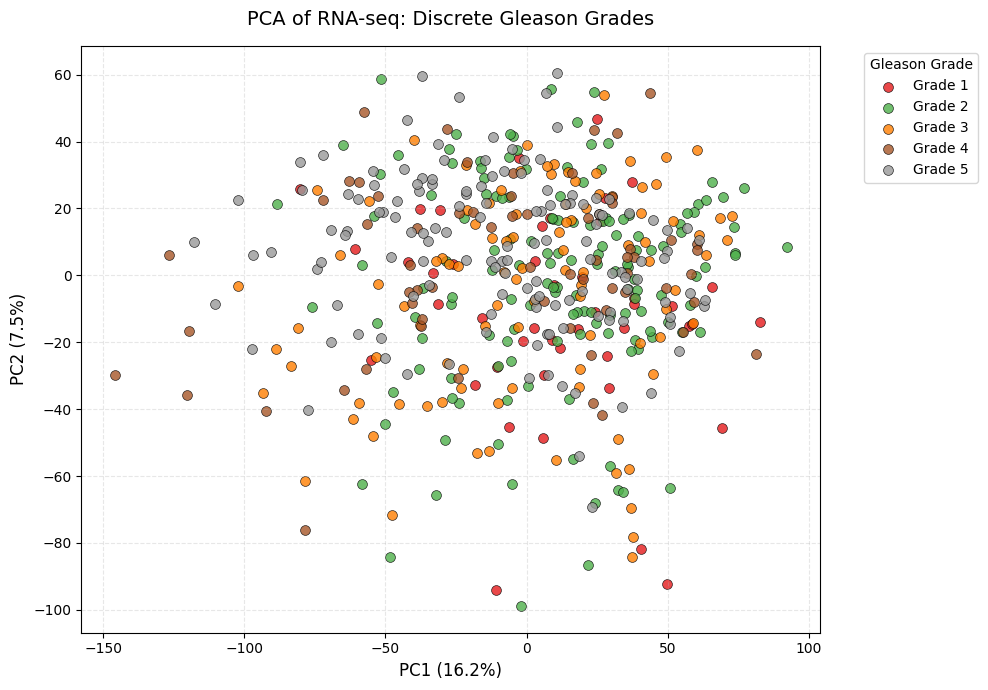

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(rna_df)

unique_grades = sorted(clin_final['grade'].unique())
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_grades)))

plt.figure(figsize=(10, 7))

for i, grade in enumerate(unique_grades):
    mask = clin_final['grade'] == grade
    plt.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        color=colors[i], 
        label=f'Grade {grade}', 
        edgecolor='black', 
        linewidth=0.5, 
        alpha=0.8,
        s=50 # Point size
    )

plt.title("PCA of RNA-seq: Discrete Gleason Grades", fontsize=14, pad=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12)

plt.legend(title="Gleason Grade", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
rna_tmp = rna_df.copy()
rna_tmp['grade'] = clin_final['grade']

mean_expr = rna_tmp.groupby('grade').mean().T

monotonic_genes = []
for gene in mean_expr.index:
    corr, p = spearmanr([1,2,3,4,5], mean_expr.loc[gene])
    if abs(corr) > 0.7 and p < 0.05:
        monotonic_genes.append(gene)

len(monotonic_genes)

2095

In [12]:
monotonic_genes

['ORM1',
 'NPY',
 'MUC6',
 'RLN1',
 'GDEP',
 'PCA3',
 'B3GNT6',
 'ALOX15B',
 'ANKRD34B',
 'PCGEM1',
 'ORM2',
 'CD177',
 'ABP1',
 'VSTM2A',
 'CST1',
 'C1orf64',
 'CYP4F8',
 'ANPEP',
 'CYP4F2',
 'CKM',
 'PGC',
 'ACTA1',
 'SLC26A3',
 'CCK',
 'DLX1',
 'ALOX15',
 'ZNF560',
 'DPYS',
 'MYH6',
 'CD38',
 'PON1',
 'ABCC11',
 'PPFIA2',
 'ATP12A',
 'ZIC2',
 'ACTC1',
 'SERPINA11',
 'CST2',
 'UNC5D',
 'SLCO1A2',
 'SLC7A4',
 'LCN2',
 'ADAM7',
 'FOXI1',
 'HBA1',
 'LOC389332',
 'PCDHA1',
 'MSMB',
 'ZIC5',
 'SHISA9',
 'CPNE6',
 'FOSB',
 'AGR3',
 'ADAM2',
 'MUC2',
 'FOXD1',
 'TFF3',
 'SLN',
 'PAH',
 'OR51E2',
 'VGLL3',
 'GSTA1',
 'SLC44A5',
 'PCOTH',
 'VSIG2',
 'PRAME',
 'BPIL1',
 'COL10A1',
 'SOHLH2',
 'COMP',
 'PCDHA6',
 'CSF3',
 'SYT4',
 'PDIA2',
 'DNAH8',
 'CGA',
 'CARTPT',
 'PHGR1',
 'CADPS',
 'AQP2',
 'PEBP4',
 'CEACAM22P',
 'KIAA1210',
 'CP',
 'C20orf114',
 'GLB1L3',
 'CFC1B',
 'POTEH',
 'FAM3B',
 'SCGB1D2',
 'GRIN3A',
 'SLC5A8',
 'DDC',
 'UGT1A1',
 'LOC728606',
 'CHI3L2',
 'C15orf48',
 'CXCL2',
 

In [13]:
df_surv = rna_df.copy()
df_surv['time'] = clin_final['time']
df_surv['event'] = clin_final['event']

cox_genes = []
for gene in rna_df.columns:
    try:
        cph = CoxPHFitter()
        cph.fit(df_surv[['time','event',gene]], 'time', 'event')
        if cph.summary.loc[gene, 'p'] < 0.05:
            cox_genes.append(gene)
    except:
        pass

In [14]:
len(cox_genes)

918

In [15]:
hybrid_genes = set(monotonic_genes).intersection(cox_genes)

In [16]:
len(hybrid_genes)

677

In [17]:
hybrid_genes

{'A2BP1',
 'ABP1',
 'ACADL',
 'ACER1',
 'ACPP',
 'ACTC1',
 'ADAM12',
 'ADAMTS14',
 'ADAMTS2',
 'ADAMTS6',
 'ADORA1',
 'ADPRHL1',
 'ADRA1D',
 'AEBP1',
 'AFF3',
 'AFP',
 'AK5',
 'AKR1C3',
 'ALDH1A1',
 'ALDH1A2',
 'ALDH2',
 'AMH',
 'AMT',
 'ANGPTL1',
 'ANKRD30A',
 'ANLN',
 'ANO4',
 'ANO7',
 'ANPEP',
 'AOX1',
 'APBA2',
 'APLN',
 'APLNR',
 'APOBEC3B',
 'APOC1',
 'APOC2',
 'APOF',
 'ARG2',
 'ARHGAP11B',
 'ARHGDIG',
 'ASF1B',
 'ASPA',
 'ASPM',
 'ASPN',
 'ATG9B',
 'ATP1A2',
 'ATP1A3',
 'ATP6V1G3',
 'AURKB',
 'AZGP1',
 'B3GALT2',
 'B4GALNT4',
 'BARX1',
 'BCAS1',
 'BCL2L14',
 'BGN',
 'BHLHE22',
 'BIRC5',
 'BMP6',
 'BMPER',
 'BTBD11',
 'BTG2',
 'BUB1',
 'BUB1B',
 'BVES',
 'C13orf38',
 'C17orf55',
 'C17orf60',
 'C18orf34',
 'C1QL3',
 'C1orf64',
 'C2',
 'C20orf103',
 'C21orf62',
 'C2orf71',
 'C2orf88',
 'C3orf72',
 'C5orf46',
 'C7',
 'C8ORFK29',
 'C9orf117',
 'C9orf172',
 'C9orf66',
 'CA14',
 'CACNG1',
 'CACNG4',
 'CALML5',
 'CAMK2N1',
 'CAMK2N2',
 'CAMP',
 'CASC5',
 'CASKIN1',
 'CASQ1',
 'CBX2',
 

In [18]:

# 1. Convert set to list
gene_list = list(hybrid_genes) 

# 2. Prepare Target (y)
y = np.array(
    [(bool(e), t) for e, t in zip(df_surv['event'], df_surv['time'])],
    dtype=[('Status', '?'), ('Time', '<f8')]
)

# 3. Prepare Features (X)
X = rna_df[gene_list]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Keeping it as numpy for speed

# 4. Setup LASSO Cox with Speed Optimizations
# tol=0.01 and max_iter help the model finish faster
lasso_cox = CoxnetSurvivalAnalysis(
    l1_ratio=1.0, 
    alpha_min_ratio=0.05, 
    tol=1e-2, 
    max_iter=1000
)

# 5. Faster GridSearchCV
# n_jobs=-1 uses all CPU cores. 10 alphas is usually enough to find a trend.
cv_model = GridSearchCV(
    lasso_cox,
    param_grid={"alphas": [[a] for a in np.logspace(-2, 0, 10)]},
    cv=5, # Reduced from 5 to 3 to save time
    n_jobs=-1 
)

# 6. Fit
print("Starting LASSO fit.")
cv_model.fit(X_scaled, y)
best_model = cv_model.best_estimator_

# 7. Extract Coefficients
# We use .squeeze() to ensure the array is 1D
coefs = best_model.coef_.squeeze()
coefficients_series = pd.Series(coefs, index=gene_list)
final_genes = coefficients_series[coefficients_series != 0].index.tolist()

print(f"Selected {len(final_genes)} genes out of {len(gene_list)}")

Starting LASSO fit.
Selected 33 genes out of 677


In [19]:
final_genes

['CAMP',
 'SERPIND1',
 'FOXN4',
 'SLC12A5',
 'OVOL1',
 'SLC14A2',
 'SLC38A5',
 'MUC6',
 'SIGLEC5',
 'PRSS27',
 'SYNGR3',
 'ITGAD',
 'CNIH2',
 'ITIH3',
 'SCN4A',
 'RIBC2',
 'VWA5B2',
 'CALML5',
 'FCGR2B',
 'BCL2L14',
 'NCRNA00230B',
 'FOSB',
 'B4GALNT4',
 'TAC1',
 'GAS2L3',
 'C9orf117',
 'PACRG',
 'RUNDC3A',
 'RDM1',
 'TIMD4',
 'ZNF541',
 'TMEM232',
 'DEPDC1']

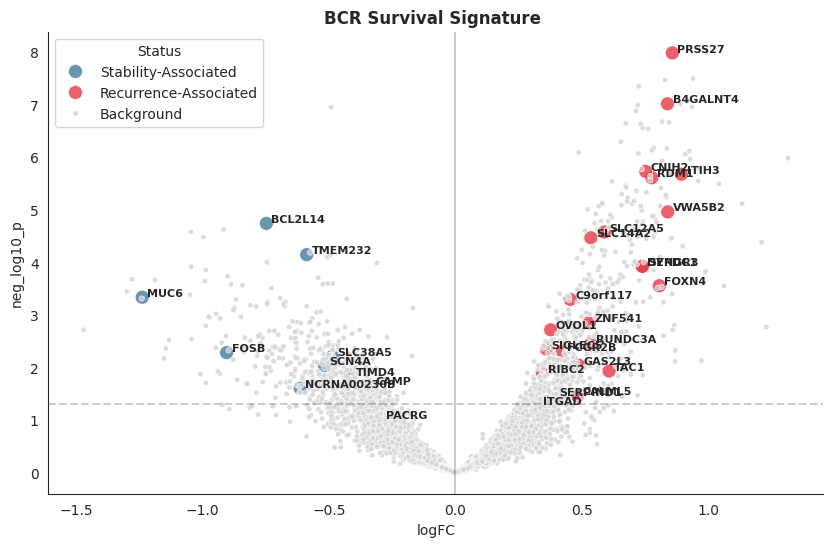

In [20]:
epsilon = 1e-10
pvals = []
logfc = []

bcr_pos = rna_df.loc[clin_final[clin_final['event'] == 1].index]
bcr_neg = rna_df.loc[clin_final[clin_final['event'] == 0].index]

for gene in rna_df.columns:
    # Welch's t-test (equal_var=False) is safer for biological data
    t, p = ttest_ind(bcr_pos[gene], bcr_neg[gene], equal_var=False)
    pvals.append(p if p > 0 else 1.0)
    logfc.append(bcr_pos[gene].mean() - bcr_neg[gene].mean())
    
volcano_df = pd.DataFrame({'gene': rna_df.columns,'logFC': logfc,'pval': pvals,'neg_log10_p': -np.log10(np.array(pvals) + epsilon)})

# Define categories for the hue mapping
volcano_df['Status'] = 'Background'
volcano_df.loc[volcano_df['gene'].isin(final_genes) & (volcano_df['logFC'] > 0), 'Status'] = 'Recurrence-Associated'
volcano_df.loc[volcano_df['gene'].isin(final_genes) & (volcano_df['logFC'] <= 0), 'Status'] = 'Stability-Associated'

plt.figure(figsize=(10, 6))
sns.set_style("white")

# Plot using hue and size mapping
ax = sns.scatterplot(
    data=volcano_df.sort_values('Status', ascending=False), # Layer LASSO genes on top
    x='logFC', y='neg_log10_p', 
    hue='Status', size='Status',
    palette={'Background': '#d3d3d3', 'Recurrence-Associated': '#e63946', 'Stability-Associated': '#457b9d'},
    sizes={'Background': 15, 'Recurrence-Associated': 100, 'Stability-Associated': 100},
    alpha=0.8, edgecolor='white', linewidth=0.5
)

# Threshold lines
plt.axhline(-np.log10(0.05), color='black', linestyle='--', alpha=0.2)
plt.axvline(0, color='black', alpha=0.2)

# Gene labels
for _, row in volcano_df[volcano_df['gene'].isin(final_genes)].iterrows():
    plt.text(row['logFC']+0.02, row['neg_log10_p']+0.02, row['gene'], fontsize=8, weight='semibold')

sns.despine()
plt.title("BCR Survival Signature ", loc='center', fontweight='bold')
plt.show()

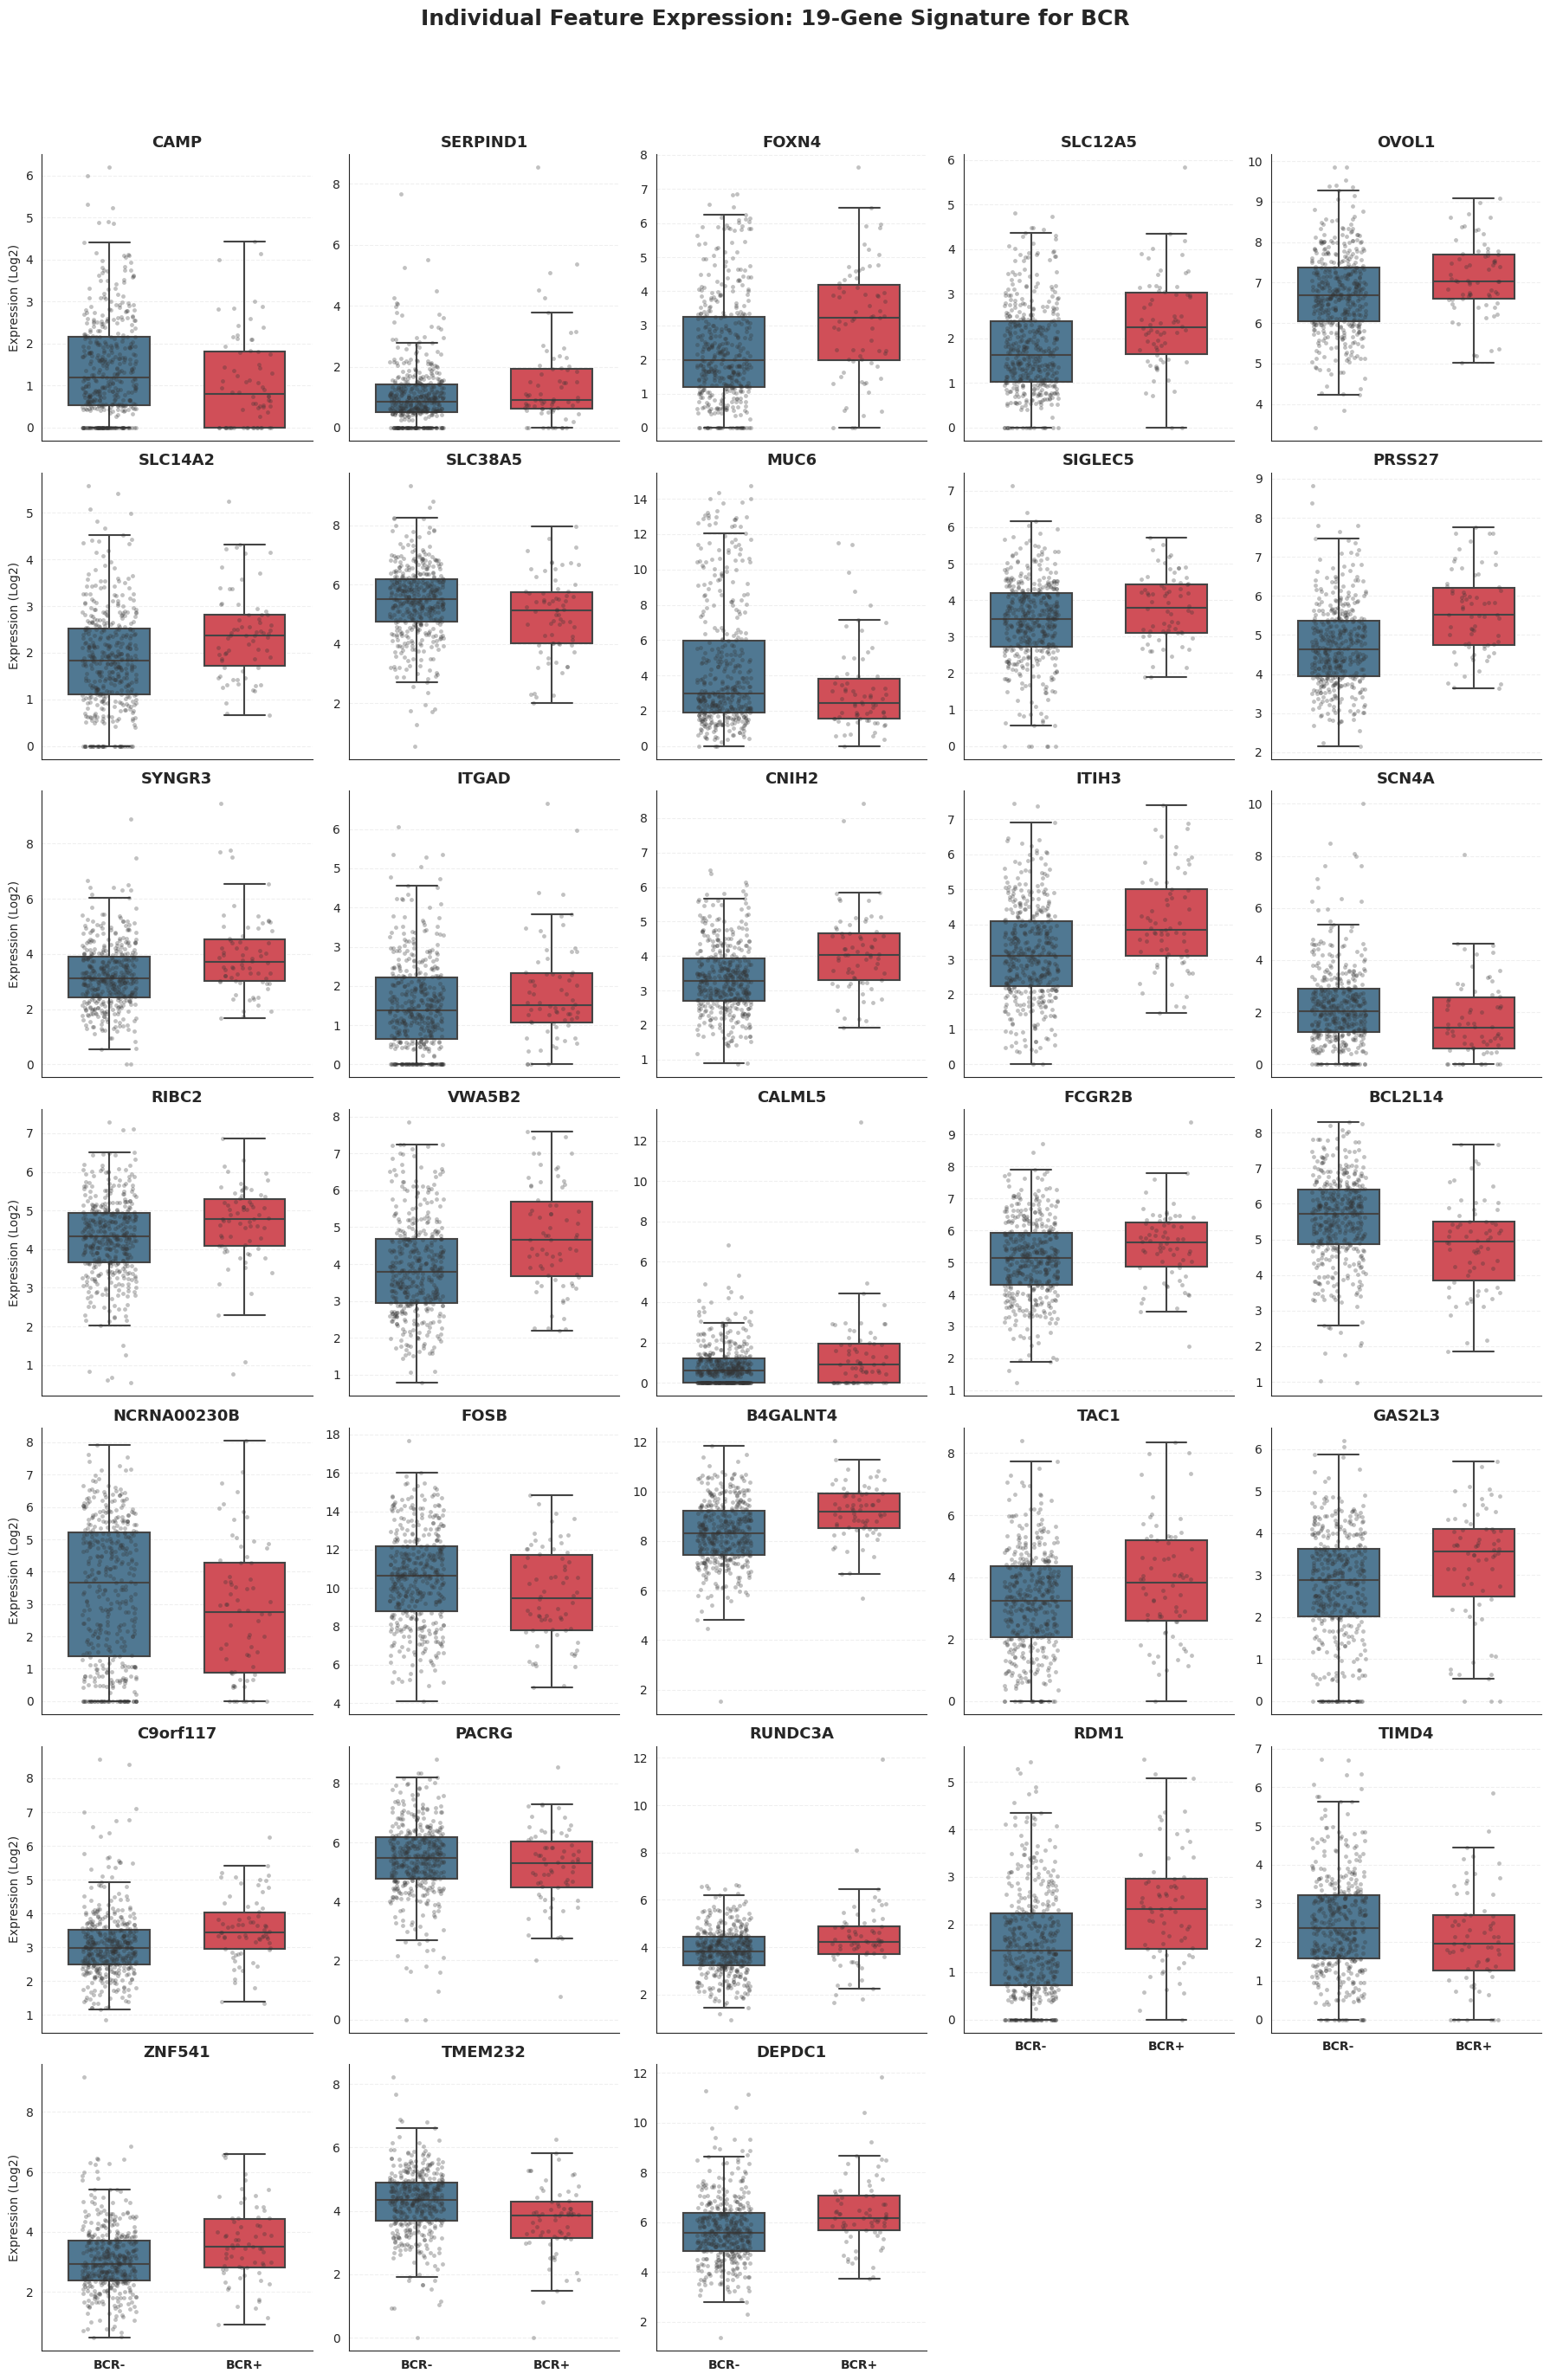

In [21]:
df_plot = rna_df[final_genes].copy()
df_plot['BCR'] = clin_final['event'].map({0: 'BCR-', 1: 'BCR+'})
df_long = df_plot.melt(id_vars='BCR', var_name='Gene', value_name='Expression')


g = sns.FacetGrid(
    df_long, 
    col="Gene", 
    col_wrap=5, 
    sharey=False, 
    height=4, 
    aspect=0.9
)

g.map_dataframe(
    sns.boxplot, 
    x="BCR", 
    y="Expression", 
    hue="BCR",
    order=['BCR-', 'BCR+'],
    palette={'BCR-': '#457b9d', 'BCR+': '#e63946'}, 
    showfliers=False, 
    width=0.6,
    linewidth=1.5,
    dodge=False 
)


g.map_dataframe(
    sns.stripplot, 
    x="BCR", 
    y="Expression", 
    order=['BCR-', 'BCR+'],
    color='#333333',
    alpha=0.3, 
    size=3.5, 
    jitter=0.2
)

g.set_titles(col_template="{col_name}", fontweight='bold', size=13)
g.set_axis_labels("", "Expression (Log2)")

for ax in g.axes:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['BCR-', 'BCR+'], fontweight='bold')
    
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    
    sns.despine(ax=ax, left=False, bottom=False)

plt.tight_layout()
plt.subplots_adjust(top=0.92) 
g.fig.suptitle('Individual Feature Expression: 19-Gene Signature for BCR', fontsize=18, fontweight='bold')

plt.show()

In [22]:
### Cox WITH Gleason

In [23]:
df_model = df_surv[['time','event'] + final_genes].copy()

cph = CoxPHFitter()
cph.fit(df_model, 'time', 'event')

print(cph.summary)

                 coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                    
CAMP        -0.128311   0.879580  0.125128       -0.373557        0.116936   
SERPIND1     0.168328   1.183325  0.141968       -0.109924        0.446580   
FOXN4        0.129485   1.138242  0.094063       -0.054876        0.313845   
SLC12A5      0.113326   1.119997  0.140148       -0.161358        0.388010   
OVOL1        0.007269   1.007296  0.171059       -0.328000        0.342539   
SLC14A2      0.281303   1.324855  0.149794       -0.012289        0.574895   
SLC38A5     -0.321492   0.725066  0.160315       -0.635704       -0.007280   
MUC6        -0.183263   0.832549  0.057085       -0.295148       -0.071378   
SIGLEC5      0.192331   1.212072  0.212545       -0.224250        0.608912   
PRSS27      -0.043185   0.957734  0.150341       -0.337848        0.251478   
SYNGR3      -0.018513   0.981658  0.127650       -0.268703      

In [24]:
### Risk score

In [25]:
risk_score = rna_df[final_genes].dot(cph.params_[:len(final_genes)])

/tmp/ipykernel_312927/2141888086.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


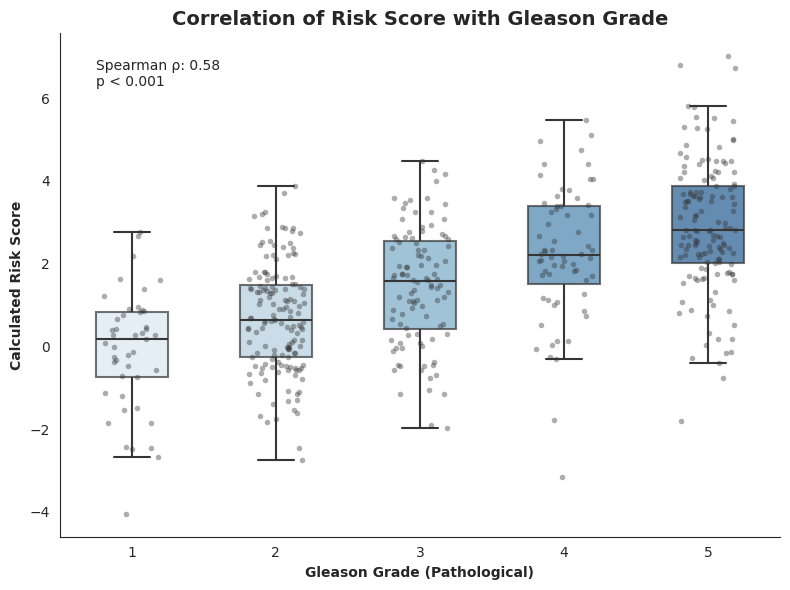

In [26]:

plot_df = pd.DataFrame({
    'Gleason': clin_final['grade'],
    'Risk Score': risk_score
})

plt.figure(figsize=(8, 6))
sns.set_style("white")


sns.boxplot(
    data=plot_df, x='Gleason', y='Risk Score', 
    palette="Blues", showfliers=False, width=0.5,
    linewidth=1.5, boxprops=dict(alpha=0.7)
)

sns.stripplot(
    data=plot_df, x='Gleason', y='Risk Score', 
    color=".2", size=4, jitter=0.2, alpha=0.4
)


corr, p_val = spearmanr(plot_df['Gleason'], plot_df['Risk Score'])
plt.text(0.05, 0.95, f'Spearman ρ: {corr:.2f}\np < 0.001', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title("Correlation of Risk Score with Gleason Grade", loc='center', fontweight='bold', fontsize=14)
plt.xlabel("Gleason Grade (Pathological)", fontweight='bold')
plt.ylabel("Calculated Risk Score", fontweight='bold')

sns.despine() # Remove top and right borders
plt.tight_layout()
plt.show()

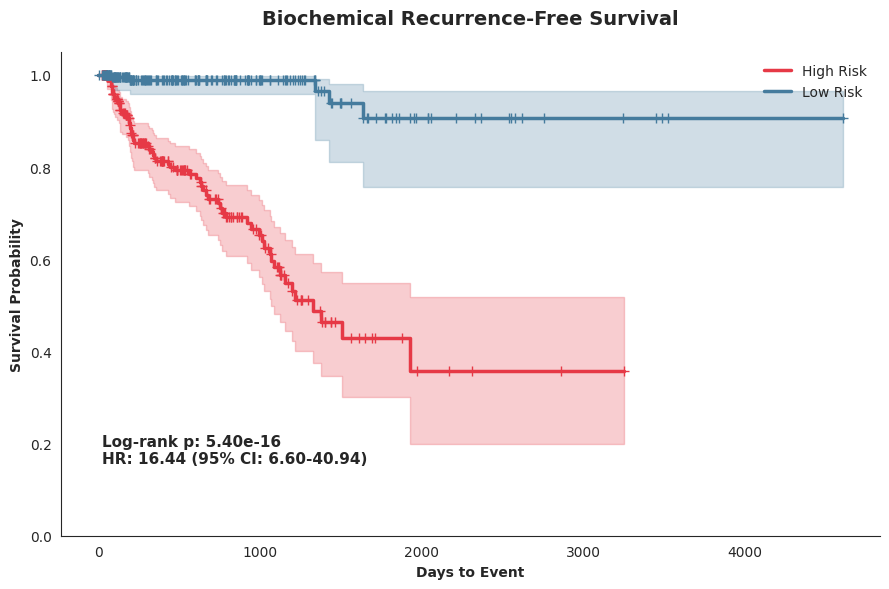

------------------------------
SURVIVAL ANALYSIS RESULTS
------------------------------
Log-Rank p-value:    5.4002e-16
Hazard Ratio (HR):   16.44
95% CI:              [6.60 - 40.94]
------------------------------
Median Survival (High Risk): 1328.0 days
Median Survival (Low Risk): Not Reached


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# 1. Prepare Data
df_km = pd.DataFrame({
    'time': clin_final['time'],
    'event': clin_final['event'],
    'group': (risk_score > risk_score.median()).map({True: 'High Risk', False: 'Low Risk'})
})

# 2. Calculate Statistics
# Log-rank test for p-value
results = logrank_test(df_km['time'][df_km['group'] == 'High Risk'], 
                       df_km['time'][df_km['group'] == 'Low Risk'], 
                       df_km['event'][df_km['group'] == 'High Risk'], 
                       df_km['event'][df_km['group'] == 'Low Risk'])
p_val = results.p_value

# Cox Proportional Hazards for HR
cph = CoxPHFitter()
# We need group as a 0/1 for CPH
df_km['is_high_risk'] = (df_km['group'] == 'High Risk').astype(int)
cph.fit(df_km[['time', 'event', 'is_high_risk']], duration_col='time', event_col='event')
hr = cph.hazard_ratios_['is_high_risk']
lower_ci = np.exp(cph.confidence_intervals_.loc['is_high_risk', '95% lower-bound'])
upper_ci = np.exp(cph.confidence_intervals_.loc['is_high_risk', '95% upper-bound'])

# 3. Plotting
plt.figure(figsize=(9, 6))
sns.set_style("white")
kmf = KaplanMeierFitter()

colors = {'High Risk': '#e63946', 'Low Risk': '#457b9d'}

for name, group in df_km.groupby('group'):
    kmf.fit(group['time'], group['event'], label=name)
    kmf.plot_survival_function(
        color=colors[name], 
        lw=2.5, 
        show_censors=True, 
        censor_styles={'marker': '+', 'mew': 1, 'ms': 7}
    )

# 4. Add Stats Annotation
stats_text = (f"Log-rank p: {p_val:.2e}\n"
              f"HR: {hr:.2f} (95% CI: {lower_ci:.2f}-{upper_ci:.2f})")

plt.annotate(stats_text, xy=(0.05, 0.15), xycoords='axes fraction', 
             fontsize=11, fontweight='bold', bbox=dict(boxstyle='round', fc='white', alpha=0.5))

# 5. Aesthetic Refinements
plt.title("Biochemical Recurrence-Free Survival", loc='center', fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Days to Event", fontweight='bold')
plt.ylabel("Survival Probability", fontweight='bold')
plt.ylim(0, 1.05)
plt.legend(frameon=False, loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

# --- PRINT STATISTICAL SUMMARY ---
print("-" * 30)
print("SURVIVAL ANALYSIS RESULTS")
print("-" * 30)
print(f"{'Log-Rank p-value:':<20} {p_val:.4e}")
print(f"{'Hazard Ratio (HR):':<20} {hr:.2f}")
print(f"{'95% CI:':<20} [{lower_ci:.2f} - {upper_ci:.2f}]")
print("-" * 30)

# Optional: Print Median Survival Time if reached
for name, group in df_km.groupby('group'):
    kmf.fit(group['time'], group['event'])
    median_survival = kmf.median_survival_time_
    status = f"{median_survival} days" if np.isfinite(median_survival) else "Not Reached"
    print(f"Median Survival ({name}): {status}")

In [28]:
X = rna_df[final_genes].copy()
y = clin_final['event']


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    )
}

results = {}

for name, model in models.items():
    aucs, accs, precs, recs, f1s = [], [], [], [], []
    
    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        
        y_prob = model.predict_proba(X_test)[:,1]
        y_pred = (y_prob > 0.5).astype(int)
        
        aucs.append(roc_auc_score(y_test, y_prob))
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred, zero_division=0))
        recs.append(recall_score(y_test, y_pred, zero_division=0))
        f1s.append(f1_score(y_test, y_pred, zero_division=0))
    
    results[name] = {
        "AUC (mean)": np.mean(aucs),
        "AUC (std)": np.std(aucs),
        "Accuracy": np.mean(accs),
        "Precision": np.mean(precs),
        "Recall": np.mean(recs),
        "F1-score": np.mean(f1s)
    }

results_df = pd.DataFrame(results).T

# Round nicely
results_df = results_df.round(3)

print(results_df)

                     AUC (mean)  AUC (std)  Accuracy  Precision  Recall  \
Random Forest             0.784      0.037     0.862      0.600   0.057   
Logistic Regression       0.810      0.027     0.844      0.429   0.257   
XGBoost                   0.823      0.039     0.858      0.582   0.200   

                     F1-score  
Random Forest           0.103  
Logistic Regression     0.320  
XGBoost                 0.264  
